In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, SubsetRandomSampler
import torchvision.models as models
from torchvision import datasets, transforms
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.manifold import TSNE
import time
import os
from glob import glob

In [28]:
USE_SUBSET = True 
N_SUBSET = 10000
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001
RANDOM_SEED = 42

In [3]:
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

In [ ]:
if USE_SUBSET:
    print(f"Using a stratified subset of {N_SUBSET} training images.")
    targets = train_dataset.targets.numpy()
    sss = StratifiedShuffleSplit(n_splits=1, test_size=None, train_size=N_SUBSET, random_state=RANDOM_SEED)
    train_indices, _ = next(sss.split(np.zeros(len(targets)), targets))
    
    train_sampler = SubsetRandomSampler(train_indices)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler)
    
    X_train_flat_subset = train_dataset.data[train_indices].numpy().reshape(N_SUBSET, -1) / 255.0
    y_train_subset = train_dataset.targets[train_indices].numpy()
else:
    print("Using the full 60,000 training images.")
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    X_train_flat_subset = train_dataset.data.numpy().reshape(60000, -1) / 255.0
    y_train_subset = train_dataset.targets.numpy()

test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

fashion_test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
fashion_test_loader = DataLoader(fashion_test_dataset, batch_size=1000, shuffle=False)

X_test_flat = test_dataset.data.numpy().reshape(10000, -1) / 255.0
y_test = test_dataset.targets.numpy()

print("Data loading complete.")

Using a stratified subset of 10000 training images.
Data loading complete.


In [6]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 30)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(30, 20)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(20, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x) 
        return x

    def get_embeddings(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        return x

In [7]:
def train_mlp(model, train_loader, criterion, optimizer, epochs):
    print(f"Training MLP for {epochs} epochs...")
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")
    print("MLP training complete.")

In [8]:
def get_mlp_preds_and_labels(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

In [9]:
def get_embeddings(model, loader):
    model.eval()
    all_embeddings = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            embeddings = model.get_embeddings(images)
            all_embeddings.append(embeddings.numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_embeddings), np.concatenate(all_labels)

In [10]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=range(10), yticklabels=range(10))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.show()

In [11]:
def plot_tsne(embeddings, labels, title):
    print(f"Running t-SNE for: {title}...")
    tsne = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=30, max_iter=1000)
    tsne_results = tsne.fit_transform(embeddings)
    
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=tsne_results[:, 0], y=tsne_results[:, 1],
        hue=labels,
        palette=sns.color_palette("tab10", 10),
        s=10,
        alpha=0.7,
        legend="full"
    )
    plt.title(title)
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
    plt.show()


--- Report 1: Model Comparison (MLP, RF, LR) ---
Training Logistic Regression...


c:\Users\HP\anaconda3\envs\aeon_cenv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LR training time: 18.36s
Training Random Forest...
RF training time: 0.76s
Training MLP for 10 epochs...
Epoch 1/10, Loss: 1.2456
Epoch 2/10, Loss: 0.5544
Epoch 3/10, Loss: 0.4335
Epoch 4/10, Loss: 0.3817
Epoch 5/10, Loss: 0.3519
Epoch 6/10, Loss: 0.3250
Epoch 7/10, Loss: 0.3052
Epoch 8/10, Loss: 0.2924
Epoch 9/10, Loss: 0.2757
Epoch 10/10, Loss: 0.2679
MLP training complete.
MLP training time: 12.68s

--- Test Set Metrics ---
Logistic Regression Accuracy: 0.9071
Logistic Regression F1-Score (Macro): 0.9055

Random Forest Accuracy: 0.9518
Random Forest F1-Score (Macro): 0.9514

MLP Accuracy: 0.9009
MLP F1-Score (Macro): 0.8996


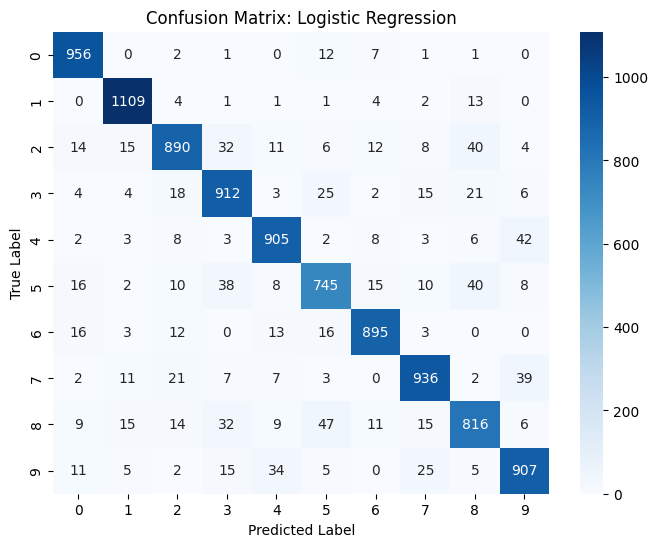

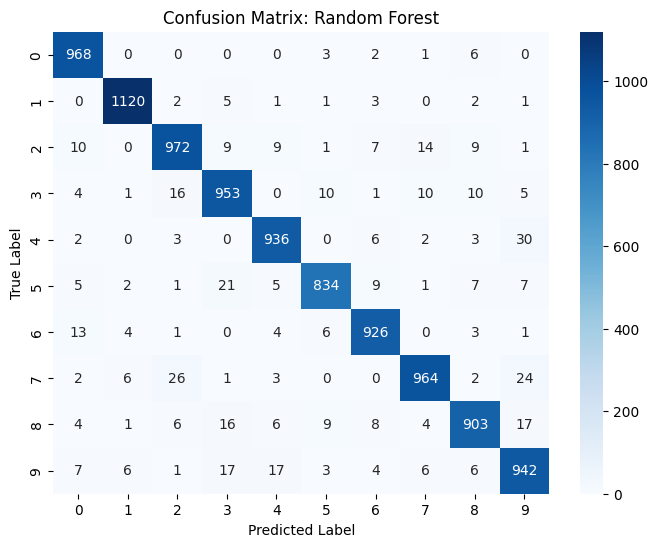

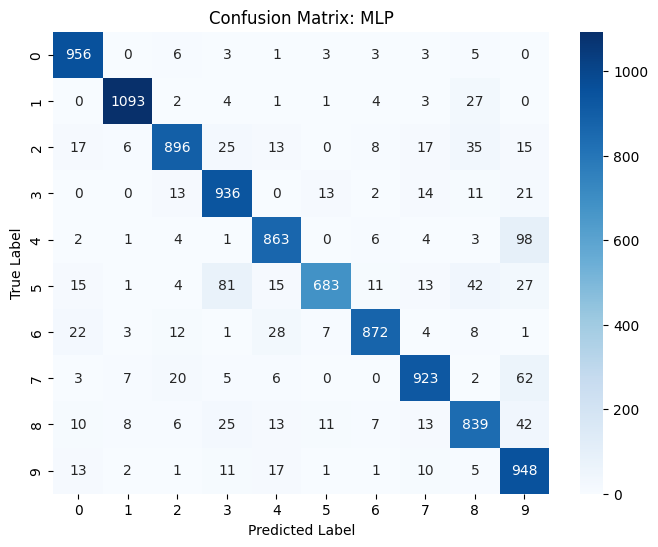

In [12]:
print("\n--- Report 1: Model Comparison (MLP, RF, LR) ---")

print("Training Logistic Regression...")
start_time = time.time()
log_reg = LogisticRegression(max_iter=100, solver='saga', n_jobs=-1, random_state=RANDOM_SEED)
log_reg.fit(X_train_flat_subset, y_train_subset)
print(f"LR training time: {time.time() - start_time:.2f}s")

y_pred_lr = log_reg.predict(X_test_flat)

print("Training Random Forest...")
start_time = time.time()
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_SEED)
rf.fit(X_train_flat_subset, y_train_subset)
print(f"RF training time: {time.time() - start_time:.2f}s")

y_pred_rf = rf.predict(X_test_flat)

mlp_trained = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mlp_trained.parameters(), lr=LEARNING_RATE)

start_time = time.time()
train_mlp(mlp_trained, train_loader, criterion, optimizer, epochs=EPOCHS)
print(f"MLP training time: {time.time() - start_time:.2f}s")

y_pred_mlp, y_true_mlp = get_mlp_preds_and_labels(mlp_trained, test_loader)

print("\n--- Test Set Metrics ---")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Logistic Regression F1-Score (Macro): {f1_score(y_test, y_pred_lr, average='macro'):.4f}")

print(f"\nRandom Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest F1-Score (Macro): {f1_score(y_test, y_pred_rf, average='macro'):.4f}")

print(f"\nMLP Accuracy: {accuracy_score(y_true_mlp, y_pred_mlp):.4f}")
print(f"MLP F1-Score (Macro): {f1_score(y_true_mlp, y_pred_mlp, average='macro'):.4f}")

plot_confusion_matrix(y_test, y_pred_lr, "Confusion Matrix: Logistic Regression")
plot_confusion_matrix(y_test, y_pred_rf, "Confusion Matrix: Random Forest")
plot_confusion_matrix(y_true_mlp, y_pred_mlp, "Confusion Matrix: MLP")



--- Report 2: t-SNE Visualization (Untrained vs. Trained) ---
Running t-SNE for: t-SNE of 20-Neuron Layer (Untrained Model)...


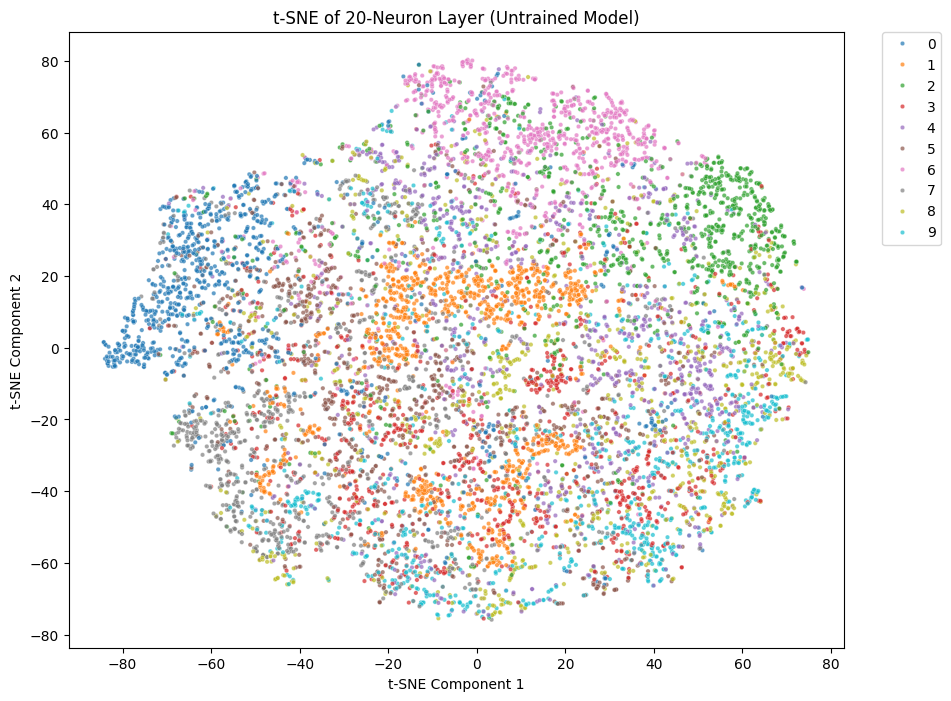

Running t-SNE for: t-SNE of 20-Neuron Layer (Trained Model on MNIST)...


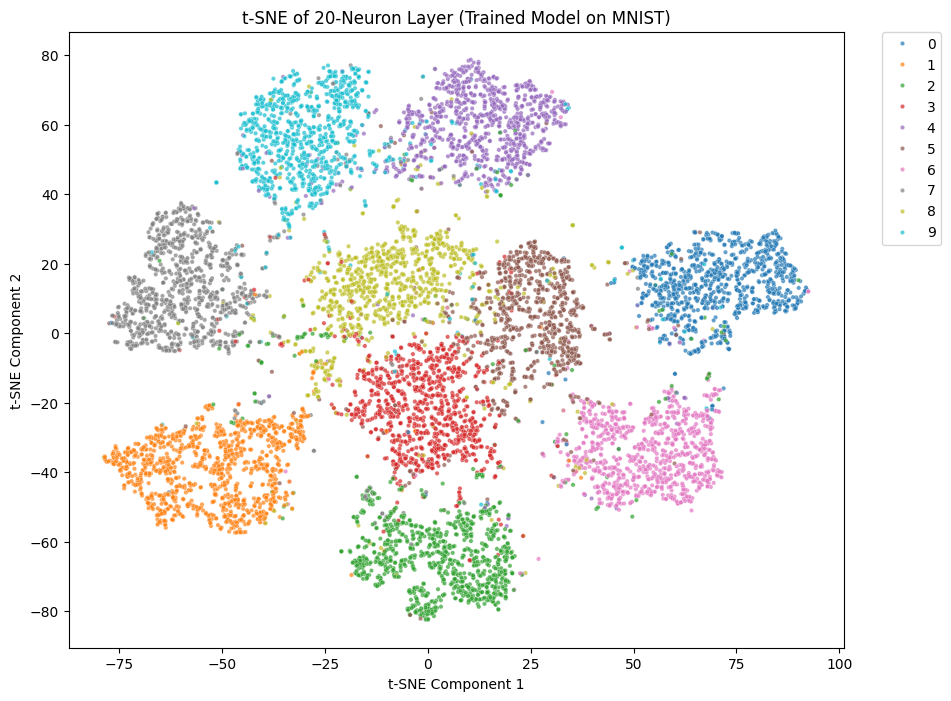


--- Report 3: Test MLP on Fashion-MNIST ---
Accuracy of MNIST-trained MLP on Fashion-MNIST: 0.0850
Running t-SNE for: t-SNE of 20-Neuron Layer (Trained on MNIST, Tested on Fashion-MNIST)...


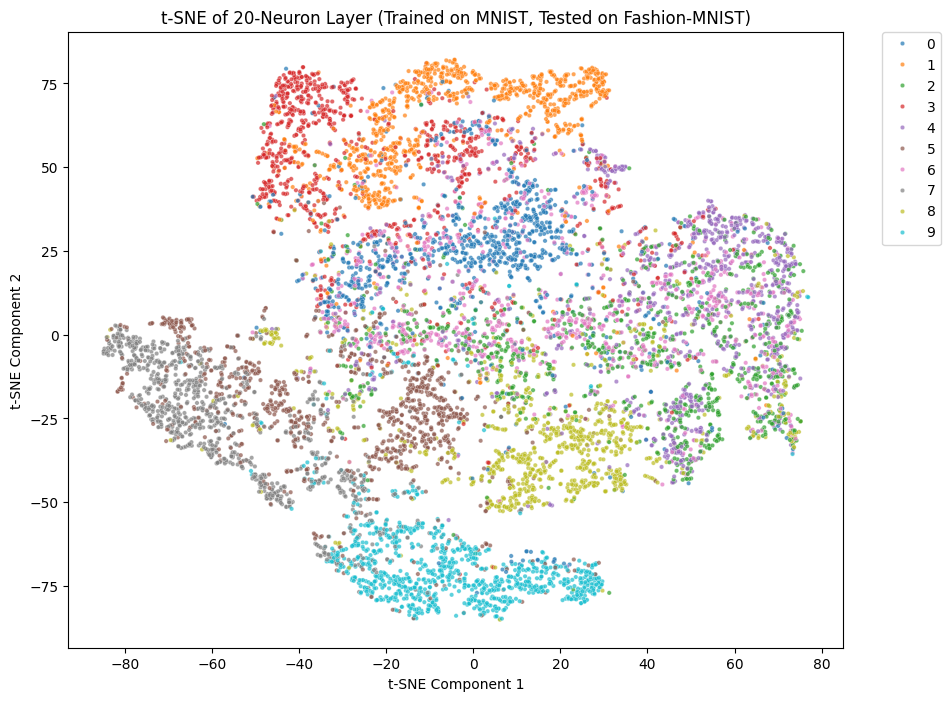

In [13]:
print("\n--- Report 2: t-SNE Visualization (Untrained vs. Trained) ---")

mlp_untrained = MLP()
embeddings_untrained, labels_untrained = get_embeddings(mlp_untrained, test_loader)
plot_tsne(embeddings_untrained, labels_untrained, "t-SNE of 20-Neuron Layer (Untrained Model)")

embeddings_trained, labels_trained = get_embeddings(mlp_trained, test_loader)
plot_tsne(embeddings_trained, labels_trained, "t-SNE of 20-Neuron Layer (Trained Model on MNIST)")

print("\n--- Report 3: Test MLP on Fashion-MNIST ---")

y_pred_fashion, y_true_fashion = get_mlp_preds_and_labels(mlp_trained, fashion_test_loader)
print(f"Accuracy of MNIST-trained MLP on Fashion-MNIST: {accuracy_score(y_true_fashion, y_pred_fashion):.4f}")

embeddings_fashion, labels_fashion = get_embeddings(mlp_trained, fashion_test_loader)
plot_tsne(embeddings_fashion, labels_fashion, "t-SNE of 20-Neuron Layer (Trained on MNIST, Tested on Fashion-MNIST)")


The accuracy of the trained_mnist_mlp on Fashion-MNIST test set is **extremely low**. This is because of **domain shift** . 
The model is an expert in recognizing features of *handwritten digits*. The Fashion-MNIST dataset contains completely different featuresWhen the model is shown an image of a "T-shirt," its learned digit-features are useless. It cannot find any patterns it recognizes, and its output is effectively random. This proves that the model did not learn a "general" concept of vision, but a highly specialized ability to classify MNIST digits.

In [ ]:
EPOCHS_CNN = 10      
EPOCHS_FT = 5     
LEARNING_RATE = 0.001
BATCH_SIZE = 16
# N_SUBSET = 1000
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


In [15]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        # Input: 1 x 28 x 28
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        # -> 32 x 28 x 28
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        # -> 32 x 14 x 14
        
        self.flatten = nn.Flatten()
        # Input features: 32 * 14 * 14 = 6272
        self.fc1 = nn.Linear(32 * 14 * 14, 128)
        self.relu2 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.flatten(x)
        x = self.relu2(self.fc1(x))
        x = self.fc2(x)
        return x

In [16]:
def train_model(model, train_loader, criterion, optimizer, epochs, model_name):
    print(f"Training {model_name} for {epochs} epochs...")
    model.train()
    model.to(DEVICE)
    for epoch in range(epochs):
        epoch_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}")
    print(f"{model_name} training complete.")

def get_preds_and_labels(model, loader):
    model.eval()
    model.to(DEVICE)
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_preds), np.array(all_labels)

def count_parameters(model):
    # Count only trainable parameters
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def measure_inference_time(model, loader):
    model.eval()
    model.to(DEVICE)
    start_time = time.time()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            model(images)
    end_time = time.time()
    return end_time - start_time

In [17]:
print("\n--- Training Simple CNN ---")
simple_cnn = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer_cnn = optim.Adam(simple_cnn.parameters(), lr=LEARNING_RATE)

# Use the original train_loader (1x28x28)
# We assume 'train_loader' and 'test_loader' are in memory
train_model(simple_cnn, train_loader, criterion, optimizer_cnn, EPOCHS_CNN, "SimpleCNN")

# Get results for Simple CNN
y_pred_cnn, y_true_cnn = get_preds_and_labels(simple_cnn, test_loader)
acc_cnn = accuracy_score(y_true_cnn, y_pred_cnn)
f1_cnn = f1_score(y_true_cnn, y_pred_cnn, average='macro')
params_cnn = count_parameters(simple_cnn)
time_cnn = measure_inference_time(simple_cnn, test_loader)

print(f"Simple CNN Trainable Params: {params_cnn}")
print(f"Simple CNN Inference Time: {time_cnn:.4f}s")


--- Training Simple CNN ---
Training SimpleCNN for 10 epochs...
Epoch 1/10, Loss: 0.6454
Epoch 2/10, Loss: 0.2244
Epoch 3/10, Loss: 0.1497
Epoch 4/10, Loss: 0.1099
Epoch 5/10, Loss: 0.0790
Epoch 6/10, Loss: 0.0624
Epoch 7/10, Loss: 0.0452
Epoch 8/10, Loss: 0.0362
Epoch 9/10, Loss: 0.0260
Epoch 10/10, Loss: 0.0220
SimpleCNN training complete.
Simple CNN Trainable Params: 804554
Simple CNN Inference Time: 1.4300s


In [45]:
def train_model_ft(
    model,
    train_loader: DataLoader,
    criterion,
    optimizer,
    epochs: int,
    model_name: str,
    save_dir: str = "checkpoints",
    checkpoint_interval: int = 2,
):
    os.makedirs(save_dir, exist_ok=True)
    model = model.to(DEVICE)

    checkpoint_files = sorted(glob(os.path.join(save_dir, f"{model_name}_epoch*.pth")))
    start_epoch = 1
    if checkpoint_files:
        latest_ckpt = checkpoint_files[-1]
        checkpoint = torch.load(latest_ckpt, map_location=DEVICE)

        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        start_epoch = checkpoint["epoch"] + 1
        print(f"Resuming from epoch: {start_epoch}")
    else:
        print("Starting a fresh run")
    for epoch in range(start_epoch, epochs + 1):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)

        print(f"Epoch [{epoch}/{epochs}] | Train Loss: {train_loss:.4f}")

        if epoch % checkpoint_interval == 0:
            ckpt_path = os.path.join(save_dir, f"{model_name}_epoch{epoch}.pth")
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
            }, ckpt_path)
            print(f"Checkpoint saved: {ckpt_path}")

    final_path = os.path.join(save_dir, f"{model_name}.pth")
    torch.save(model.state_dict(), final_path)
    print(f"Final model saved: {final_path}")

In [46]:
print("\n--- Preparing Data for Pretrained Models ---")
pretrained_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset_pre = datasets.MNIST(root='./data', train=True, download=True, transform=pretrained_transform)
test_dataset_pre = datasets.MNIST(root='./data', train=False, download=True, transform=pretrained_transform)

if USE_SUBSET:
    train_sampler_pre = SubsetRandomSampler(train_indices)
    train_loader_pre = DataLoader(train_dataset_pre, batch_size=BATCH_SIZE, sampler=train_sampler_pre)
    test_indices = torch.randperm(len(test_dataset_pre))[:1000]
    test_sampler_pre = SubsetRandomSampler(test_indices)
    test_loader_pre = DataLoader(test_dataset_pre, batch_size=100, sampler=test_sampler_pre)

else:
    train_loader_pre = DataLoader(train_dataset_pre, batch_size=BATCH_SIZE, shuffle=True)
    test_loader_pre = DataLoader(test_dataset_pre, batch_size=1000, shuffle=False)
print("Pretrained data loaders are ready.")



--- Preparing Data for Pretrained Models ---
Pretrained data loaders are ready.


In [47]:
len(test_loader_pre)

10

In [48]:
print("\n--- Training MobileNetV2 ---")
mobilenet = models.mobilenet_v2(weights='DEFAULT')

# Freeze all parameters
for param in mobilenet.parameters():
    param.requires_grad = False

# Replace the final classifier layer
num_ftrs_mobile = mobilenet.classifier[1].in_features
mobilenet.classifier[1] = nn.Linear(num_ftrs_mobile, 10)

# Only the new classifier's parameters will be trained
optimizer_mobile = optim.Adam(mobilenet.classifier[1].parameters(), lr=LEARNING_RATE)

train_model_ft(mobilenet, train_loader_pre, criterion, optimizer_mobile, EPOCHS_FT, "MobileNetV2")

# Get results for MobileNetV2
y_pred_mobile, y_true_mobile = get_preds_and_labels(mobilenet, test_loader_pre)
acc_mobile = accuracy_score(y_true_mobile, y_pred_mobile)
f1_mobile = f1_score(y_true_mobile, y_pred_mobile, average='macro')
params_mobile = count_parameters(mobilenet)
time_mobile = measure_inference_time(mobilenet, test_loader_pre)

print(f"MobileNetV2 Trainable Params: {params_mobile}")
print(f"MobileNetV2 Inference Time: {time_mobile:.4f}s")


--- Training MobileNetV2 ---
Starting a fresh run
Epoch [1/3] | Train Loss: 1.2428
Epoch [2/3] | Train Loss: 0.6168
Checkpoint saved: checkpoints\MobileNetV2_epoch2.pth
Epoch [3/3] | Train Loss: 0.4657
Final model saved: checkpoints\MobileNetV2.pth
MobileNetV2 Trainable Params: 12810
MobileNetV2 Inference Time: 26.3970s


In [ ]:
print("\n--- Training EfficientNet-B0 ---")
efficientnet = models.efficientnet_b0(weights='DEFAULT')

for param in efficientnet.parameters():
    param.requires_grad = False


num_ftrs_effnet = efficientnet.classifier[1].in_features
efficientnet.classifier[1] = nn.Linear(num_ftrs_effnet, 10)

optimizer_effnet = optim.Adam(efficientnet.classifier[1].parameters(), lr=LEARNING_RATE)

train_model_ft(efficientnet, train_loader_pre, criterion, optimizer_effnet, EPOCHS_FT, "EfficientNet-B0")


y_pred_effnet, y_true_effnet = get_preds_and_labels(efficientnet, test_loader_pre)
acc_effnet = accuracy_score(y_true_effnet, y_pred_effnet)
f1_effnet = f1_score(y_true_effnet, y_pred_effnet, average='macro')
params_effnet = count_parameters(efficientnet)
time_effnet = measure_inference_time(efficientnet, test_loader_pre)

print(f"EfficientNet-B0 Trainable Params: {params_effnet}")
print(f"EfficientNet-B0 Inference Time: {time_effnet:.4f}s")


--- Training EfficientNet-B0 ---
Starting a fresh run
Epoch [1/3] | Train Loss: 0.9766
Epoch [2/3] | Train Loss: 0.4757
Checkpoint saved: checkpoints\EfficientNet-B0_epoch2.pth
Epoch [3/3] | Train Loss: 0.3849
Final model saved: checkpoints\EfficientNet-B0.pth
EfficientNet-B0 Trainable Params: 12810
EfficientNet-B0 Inference Time: 25.8989s



--- 📊 Final Model Comparison ---
| Model | Accuracy | F1-Score (Macro) | Trainable Params | Inference Time (s) |
|---|---|---|---|---|
| Simple CNN | 0.9677 | 0.9674 | 804,554 | 1.4300 |
| MobileNetV2 (Fine-tuned) | 0.8920 | 0.8883 | 12,810 | 26.3970 |
| EfficientNet-B0 (Fine-tuned) | 0.9310 | 0.9289 | 12,810 | 25.8989 |


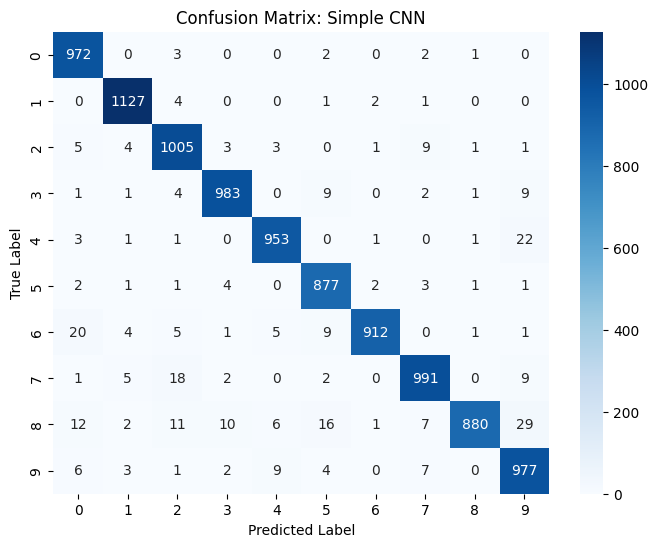

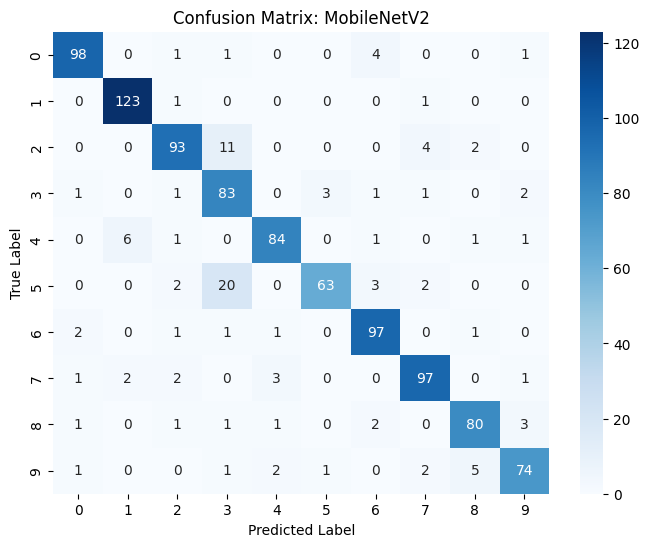

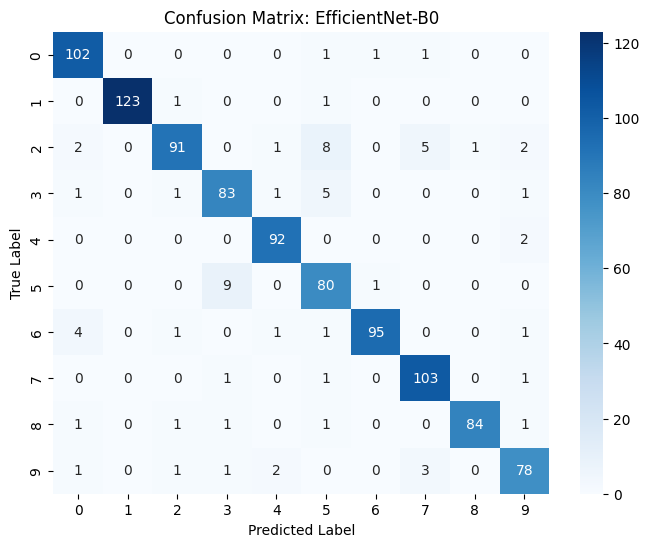

In [50]:
print("\n--- 📊 Final Model Comparison ---")

# Data for the table
data = {
    "Model": ["Simple CNN", "MobileNetV2 (Fine-tuned)", "EfficientNet-B0 (Fine-tuned)"],
    "Accuracy": [f"{acc_cnn:.4f}", f"{acc_mobile:.4f}", f"{acc_effnet:.4f}"],
    "F1-Score (Macro)": [f"{f1_cnn:.4f}", f"{f1_mobile:.4f}", f"{f1_effnet:.4f}"],
    "Trainable Params": [f"{params_cnn:,}", f"{params_mobile:,}", f"{params_effnet:,}"],
    "Inference Time (s)": [f"{time_cnn:.4f}", f"{time_mobile:.4f}", f"{time_effnet:.4f}"]
}

print("| Model | Accuracy | F1-Score (Macro) | Trainable Params | Inference Time (s) |")
print("|---|---|---|---|---|")
for i in range(len(data["Model"])):
    print(f"| {data['Model'][i]} | {data['Accuracy'][i]} | {data['F1-Score (Macro)'][i]} | {data['Trainable Params'][i]} | {data['Inference Time (s)'][i]} |")

# Plot Confusion Matrices
plot_confusion_matrix(y_true_cnn, y_pred_cnn, "Confusion Matrix: Simple CNN")
plot_confusion_matrix(y_true_mobile, y_pred_mobile, "Confusion Matrix: MobileNetV2")
plot_confusion_matrix(y_true_effnet, y_pred_effnet, "Confusion Matrix: EfficientNet-B0")